# Reflectancias HLB

Procesamiento de espectros obtenidos para la campaña de medición como

$$
\rho_{sample} = \rho_{spectralon}\frac{L_{sample}}{L_{spectralon}}
$$

In [1]:
#!pip install git+https://github.com/fnemina/SpecDAL


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import specdal
from tqdm.notebook import tqdm

## Corrección del espectro

In [2]:
# Leo la reflectancia del spectralon
spectralon_9443 = specdal.readers.read_asd("../datos/abs182853-9443.ref")
rho_spectralon = specdal.Spectrum(name="Espectralon 9443", measurement=spectralon_9443[0]["tgt_reflect"], metadata=spectralon_9443[1], measure_type="tgt_reflect")

# Leo el factor de forma
shapefactor = pd.read_csv("../datos/shapefactor_cn.csv", index_col=0)['P5(l<1000)+P5(l<500)']
shapefactor = specdal.Spectrum(name="Corrección de forma", measurement=shapefactor, metadata={}, measure_type="tgt_reflect")

# Factor de reflectancia
rho_factor = shapefactor*rho_spectralon

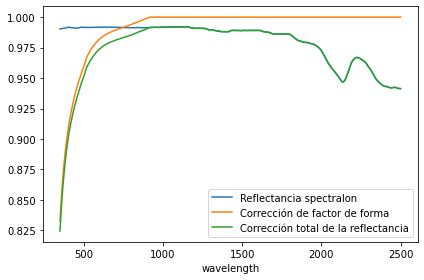

In [3]:
# Grafico las dos
rho_spectralon.plot(label="Reflectancia spectralon")
shapefactor.plot(label="Corrección de factor de forma")
rho_factor.plot(label="Corrección total de la reflectancia")
plt.legend()
plt.tight_layout()
plt.show()

## Leo la planilla de campo

In [4]:
# Leo el dataframe de la capaña
relevamiento_auxiliar = pd.read_csv("../datos/Relevamiento_Radiometro_Entre_Rios_con_molecular.csv",
                                    sep=",", encoding='latin-1')
# Convierto la columna del id_espectro_planta en el indice
relevamiento_auxiliar = relevamiento_auxiliar.set_index("id_espectro_planta")

In [5]:
# Puedo mirar un espectro usando loc
relevamiento_auxiliar.loc["L29"]

start                                                                     16/5/2023
end                                                                       16/5/2023
_ubicacion_latitude                                                      -30.804489
_ubicacion_longitude                                                      -57.92771
lat_nav                                                                   -30.80447
long_nav                                                                 -57.927731
_ubicacion_altitude                                                            69.3
_ubicacion_precision                                                          4.433
gps_garmin                                                                      651
hora_inicio_planta                                                         13:55:00
id_inta                                                                         C23
sintoma_hlb                                                                 

## Lectura de espectros

In [6]:
# Valores a enmascarar
masks = [(1350,1425),(1800,1975), (2450, 2500)]

In [7]:
prefolder = "../datos/chajari_mayo2023/radiometro/datos_chajari/"  # Carpeta del día de medición
subfolder = "/Radiometria/Rad CorrPar/"   # Subcarpeta con los datos

In [8]:
# Creo una coleccion para guardar tod
c_campaign = specdal.Collection(name="Campaña Chajari", metadata={})

# Recorro cada carpeta de cada dia
for folder_tmp in tqdm(os.listdir(prefolder)):
    # Ignoro la carpeta si no es de Chajari
    if "Chajari" not in folder_tmp: continue
    folder = prefolder+folder_tmp+"/"
    # Recorro todos los archivos de la campaña
    for foldername in tqdm(os.listdir(folder), leave=False):
        # Creo una colección vacia para procesar la campaña
        c_tmp = specdal.Collection(name="Campaña Chajari", metadata={})
        c_tmp.read(folder+foldername+subfolder, measure_type="tgt_radiance", ext=[".pco"], reader=".asd")
        # Leer todos los archivos de cada planta
        for spectra in c_tmp.spectra:
            name = spectra.name
            name = name.removesuffix(".asd.rad")      # Le saco el final
            name = name.replace("CHAJARI","CHAJARI-") # Separo despues de Chajari
            name = name[:-3]+"-"+name[-3:]            # Separo con un guion el numero de medicion

            # Determino el tipo de medición
            idx = int(name.split("-")[-1])//10        # Me quedo con la parte de las decenas
            if idx == 9:                              # Si la decena es 90, idx=9, es suelo
                kind = "soil"
            elif idx % 2 == 0:                        # Si la decena es par, idx%2=0, es espectralon
                kind = "spec"
            elif idx % 2 == 1:                        # Si la decena es impart, idx%2=1, es vegetacion
                kind = "vege"
            name = name+f"-{kind}"

            # Agrego si tengo sintoma o no
            hlb = relevamiento_auxiliar.loc[foldername.split("-")[0]].molecular
            name = name+f"-H{hlb}"
            
            # Incluir
            inc = relevamiento_auxiliar.loc[foldername.split("-")[0]].incluir
            name = name+f"-I{inc}"

            spectra.name = name                       # Cambio el nombre

        c_split = c_tmp.groupby("-",[-3])

        # Grafico las mediciones
        fig, ax = plt.subplots(nrows=3, sharex=True)
        for i, kind in enumerate(["spec","vege","soil"]):
            val = c_split[kind]
            val.plot(ax=ax[i], color = "C0", alpha=0.1)
            val.mean().plot(ax=ax[i], color = "C1")
            ax[i].set_title(kind)
            ax[i].legend().remove()
            ax[i].set_xlabel("")
        # Hago bonito el grafico
        fig.add_subplot(111, frameon=False)
        plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
        plt.xlabel(r"$\lambda$[nm]")
        plt.ylabel(r"$L[W/m^2/sr/nm]$")
        plt.plot([],[],label="Mediciones")
        plt.plot([],[],label="Promedio")
        plt.legend()
        plt.tight_layout()
        # Lo guardo
        plt.savefig(f"../figuras/molecular/fig-{foldername.split('-')[0]}.png",dpi=300)
        plt.close()

        # Calculo las reflectancias
        Lspec = c_split["spec"].mean()
        Lvege = c_split["vege"].mean()
        Lsoil = c_split["soil"].mean()
        setattr(Lspec,"metadata",{})
        setattr(Lvege,"metadata",{})
        setattr(Lsoil,"metadata",{})

        rho_vege = rho_factor*Lvege/Lspec
        rho_soil = rho_factor*Lsoil/Lspec

        # Le cambio el nombre
        rho_vege.name = "-".join(name.split("-")[:4])+"-"+"-".join(name.split("-")[6:])+"-vege"
        rho_soil.name = "-".join(name.split("-")[:4])+"-"+"-".join(name.split("-")[6:])+"-soil"
        

        # Enmascaro las zonas de altas absorciones
        for lrange in masks:
            lmin,lmax = lrange
            rho_vege.measurement.loc[lmin:lmax]=np.nan
            rho_soil.measurement.loc[lmin:lmax]=np.nan

        # Lo agrego al dataframe de la campaña
        c_campaign.append(rho_vege)
        c_campaign.append(rho_soil)
        
        # Grafico reflectancias
        rho_vege.plot(color="C2", label="Planta")
        rho_soil.plot(color="C0", label="Suelo")
        fig.add_subplot(111, frameon=False)
        plt.xlabel(r"$\lambda$[nm]")
        plt.ylabel(r"$\rho$")
        plt.legend()
        plt.tight_layout()
        # Lo guardo
        plt.savefig(f"../figuras/fig-{foldername.split('-')[0]}_ref.png",dpi=300)
        plt.close()

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

In [9]:
# Guardo los datos en un csv
c_campaign.to_csv("../datos/data-rho-chajari_con_molecular.csv")

## Trabajo con la campaña por separado

In [10]:
# Leo los datos que guarde
df_campaign = pd.read_csv("../datos/data-rho-chajari_con_molecular.csv", index_col=0)
c_campaign = specdal.df_to_collection(df_campaign, name="Chajari")

C:\Users\Usuario\anaconda3\envs\Curso_PDIS\lib\site-packages\specdal\operators\proximal_join.py:17: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  isdigit = df.columns.map(str).str.replace('.', '').str.isdigit()


In [11]:
df_campaign

,350.0,351.0,352.0,353.0,354.0,355.0,356.0,357.0,358.0,359.0,...,2491.0,2492.0,2493.0,2494.0,2495.0,2496.0,2497.0,2498.0,2499.0,2500.0
207-20230515-CHAJARI-01-Hsi-Isi-vege,0.023985,0.023950,0.023481,0.023605,0.023727,0.023706,0.023796,0.023812,0.023764,0.023657,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207-20230515-CHAJARI-01-Hsi-Isi-soil,0.028573,0.028663,0.028431,0.028543,0.028768,0.028994,0.029233,0.029325,0.029413,0.029509,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207-20230515-CHAJARI-10-Hno-Isi-vege,0.015542,0.015553,0.015620,0.015665,0.015660,0.015668,0.015792,0.015846,0.015812,0.015754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207-20230515-CHAJARI-10-Hno-Isi-soil,0.008876,0.008870,0.008920,0.008874,0.008842,0.008916,0.009127,0.009166,0.009156,0.009198,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
207-20230515-CHAJARI-11-Hsi-Isi-vege,0.010973,0.010946,0.010991,0.010948,0.010875,0.010860,0.010976,0.010967,0.010946,0.010977,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210-20230518-CHAJARI-61-Hno-Ino-soil,0.033761,0.034186,0.034975,0.035281,0.035590,0.036023,0.036374,0.036572,0.036852,0.037112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210-20230518-CHAJARI-62-Hno-Ino-vege,0.016266,0.016326,0.016372,0.016427,0.016407,0.016383,0.016523,0.016595,0.016597,0.016564,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210-20230518-CHAJARI-62-Hno-Ino-soil,0.012450,0.012417,0.012489,0.012567,0.012606,0.012639,0.012755,0.013015,0.013106,0.013001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
210-20230518-CHAJARI-63-Hno-Ino-vege,0.022237,0.022295,0.022371,0.022444,0.022459,0.022504,0.022738,0.022845,0.022822,0.022761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Separo los datos del suelo
gb_campaign = c_campaign.groupby("-",[-1])
gb_soil = gb_campaign['soil']

# Separo en cuatro mi base de datos
gb_campaign = c_campaign.groupby("-",[-1,-2,-3])

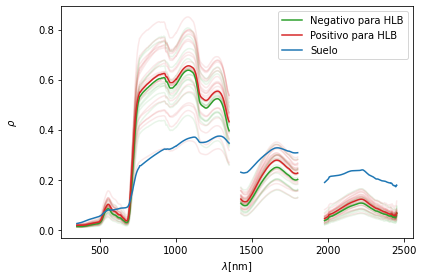

In [13]:
fig, ax = plt.subplots()

gb_campaign['vege-Isi-Hno'].plot(ax=ax, color="C2", alpha=0.1)
gb_campaign['vege-Isi-Hsi'].plot(ax=ax, color="C3", alpha=0.1)
plt.legend().remove()
fig.add_subplot(111, frameon=False)
gb_campaign['vege-Isi-Hno'].mean().plot(ax=ax, color="C2", label="Sin HLB")
gb_campaign['vege-Isi-Hsi'].mean().plot(ax=ax, color="C3", label="Con HLB")
gb_soil.mean().plot(ax=ax, color="C0", label="Suelo")
plt.xlabel(r"$\lambda$[nm]")
plt.ylabel(r"$\rho$")
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)

plt.plot([],[],"C2",label="Negativo para HLB")
plt.plot([],[],"C3",label="Positivo para HLB")
plt.plot([],[],"C0",label="Suelo")
plt.legend()
plt.tight_layout()
plt.savefig("../figuras/molecular/fig-reflectancias_molecular.png", dpi=300)
plt.show()

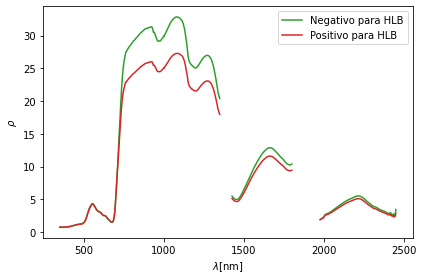

In [14]:
fig, ax = plt.subplots()

gb_campaign['vege-Isi-Hno'].mean().normalize(440).plot(ax=ax, color="C2", label="Negativo para HLB")
gb_campaign['vege-Isi-Hsi'].mean().normalize(440).plot(ax=ax, color="C3", label="Positivo para HLB")
plt.xlabel(r"$\lambda$[nm]")
plt.ylabel(r"$\rho$")
plt.legend()
plt.tight_layout()
#plt.title("Normalizado 440nm")
#plt.title("Firmas espectrales RADIOMETRO normalizadas en el azul")

plt.savefig("../figuras/molecular/fig-reflectancias-normalizada_440_molecular.png", dpi=300)
#plt.savefig("../figuras/molecular/figuras_titulo/fig-reflectancias-normalizada_440.png", dpi=300)
plt.show()

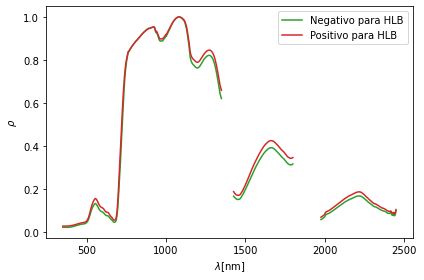

In [15]:
fig, ax = plt.subplots()

gb_campaign['vege-Isi-Hno'].mean().normalize().plot(ax=ax, color="C2", label="Negativo para HLB")
gb_campaign['vege-Isi-Hsi'].mean().normalize().plot(ax=ax, color="C3", label="Positivo para HLB")
plt.xlabel(r"$\lambda$[nm]")
plt.ylabel(r"$\rho$")
plt.legend()
plt.tight_layout()
#plt.title("Normalizado Maximo")
#plt.title("Firmas espectrales RADIOMETRO normalizadas en el máximo")

plt.savefig("../figuras/molecular/fig-reflectancias-normalizadas_maximo_molecular.png", dpi=300)
#plt.savefig("../figuras/molecular/figuras_titulo/fig-reflectancias-normalizadas_maximo.png", dpi=300)
plt.show()

In [16]:
#genero csv para cada promedio de firmas

gb_campaign['vege-Isi-Hno'].mean().to_csv("../datos/vegetacion-sin-HLB_con_molecular.csv")
gb_campaign['vege-Isi-Hsi'].mean().to_csv("../datos/vegetacion-con-HLB_con_molecular.csv")
gb_soil.mean().to_csv("../datos/suelo_con_molescular.csv")

Error estándar de la media

$\sigma _{x} = \frac{\sigma }{\sqrt{n}}$

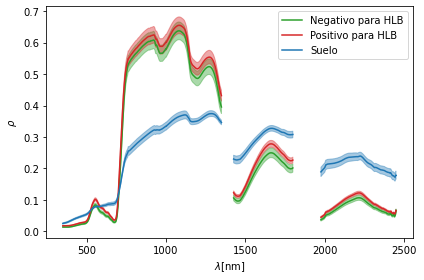

In [17]:
#Desvío estandar del promedio, error estándar de la media

fig, ax = plt.subplots()

std_no = gb_campaign['vege-Isi-Hno'].std()/np.sqrt(len(gb_campaign['vege-Isi-Hno'].spectra))
std_si = gb_campaign['vege-Isi-Hsi'].std()/np.sqrt(len(gb_campaign['vege-Isi-Hsi'].spectra))
std_soil = gb_soil.std()/np.sqrt(len(gb_soil.spectra))

mean_no = gb_campaign['vege-Isi-Hno'].mean()
mean_si = gb_campaign['vege-Isi-Hsi'].mean()
mean_soil = gb_soil.mean()

mean_no.plot(ax=ax, color="C2", label="Negativo para HLB")
mean_si.plot(ax=ax, color="C3", label="Positivo para HLB")
mean_soil.plot(ax=ax, color="C0", label="Suelo")

x = mean_no.measurement.index.values
plt.fill_between(x, mean_no-std_no, mean_no+std_no, color="C2", alpha=0.4)
plt.fill_between(x, mean_si-std_si, mean_si+std_si, color="C3", alpha=0.4)
plt.fill_between(x, mean_soil-std_soil, mean_soil+std_soil, color="C0", alpha=0.4)


#gb_soil.mean().plot(ax=ax, color="C0", label="Suelo")
plt.xlabel(r"$\lambda$[nm]")
plt.ylabel(r"$\rho$")

plt.legend()
plt.tight_layout()
plt.savefig("../figuras/molecular/fig-reflectancias_mean_std_error_molecular.png", dpi=300)
plt.show()

In [18]:
np.sqrt(len(gb_campaign['vege-Isi-Hno'].spectra))
np.sqrt(len(gb_campaign['vege-Isi-Hsi'].spectra))
np.sqrt(len(gb_soil.spectra))

7.937253933193772

In [19]:
len(gb_campaign['vege-Isi-Hno'].spectra)

12

In [20]:
len(gb_campaign['vege-Isi-Hsi'].spectra)

22

In [21]:
len(gb_soil.spectra)

63

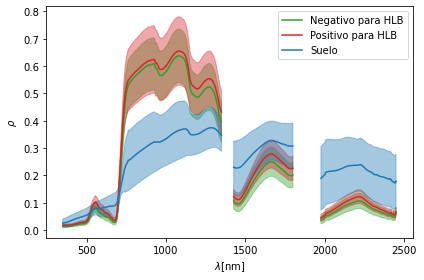

In [22]:
#Desvio estandar de las observaciones

fig, ax = plt.subplots()

std_no = gb_campaign['vege-Isi-Hno'].std()
std_si = gb_campaign['vege-Isi-Hsi'].std()
std_soil = gb_soil.std()

mean_no = gb_campaign['vege-Isi-Hno'].mean()
mean_si = gb_campaign['vege-Isi-Hsi'].mean()
mean_soil = gb_soil.mean()

mean_no.plot(ax=ax, color="C2", label="Negativo para HLB")
mean_si.plot(ax=ax, color="C3", label="Positivo para HLB")
mean_soil.plot(ax=ax, color="C0", label="Suelo")

x = mean_no.measurement.index.values
plt.fill_between(x, mean_no-std_no, mean_no+std_no, color="C2", alpha=0.4)
plt.fill_between(x, mean_si-std_si, mean_si+std_si, color="C3", alpha=0.4)
plt.fill_between(x, mean_soil-std_soil, mean_soil+std_soil, color="C0", alpha=0.4)


#gb_soil.mean().plot(ax=ax, color="C0", label="Suelo")
plt.xlabel(r"$\lambda$[nm]")
plt.ylabel(r"$\rho$")

plt.legend()
plt.tight_layout()
plt.savefig("../figuras/molecular/fig-reflectancias_mean_std_molecular.png", dpi=300)
plt.show()

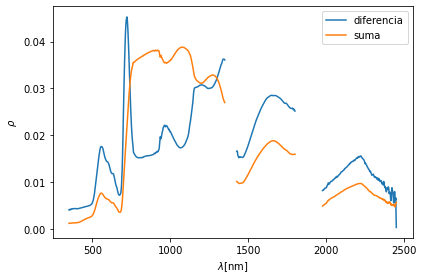

In [23]:
# la diferencia entre las medias es menor que la suma de los errores?

fig, ax = plt.subplots()

std_no = gb_campaign['vege-Isi-Hno'].std()/np.sqrt(len(gb_campaign['vege-Isi-Hno'].spectra))
std_si = gb_campaign['vege-Isi-Hsi'].std()/np.sqrt(len(gb_campaign['vege-Isi-Hsi'].spectra))
std_soil = gb_soil.std()/np.sqrt(len(gb_soil.spectra))
std_sum = np.sqrt(std_no**2 + std_si**2)

mean_no = gb_campaign['vege-Isi-Hno'].mean()
mean_si = gb_campaign['vege-Isi-Hsi'].mean()
mean_dif = np.abs(mean_no - mean_si)


mean_soil = gb_soil.mean()

mean_dif.plot(label= "diferencia") 
std_sum.plot(label = "suma")
    
#gb_soil.mean().plot(ax=ax, color="C0", label="Suelo")
plt.xlabel(r"$\lambda$[nm]")
plt.ylabel(r"$\rho$")

plt.legend()
plt.tight_layout()
plt.savefig("../figuras/molecular/fig-reflectancias_mean_std_diferencia_molecular.png", dpi=300)
plt.show()